In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42


def fijar_semilla(seed=SEED):
    """Fija las semillas para que los resultados sean reproducibles."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()

if torch.backends.mps.is_available():      # GPU de Apple (Mac M1/M2/M3...)
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():            # GPU NVIDIA
    DEVICE = torch.device("cuda")
else:                                      # CPU
    DEVICE = torch.device("cpu")

FAST_MODE = True

EPOCAS_CNN = 10 if FAST_MODE else 25       # LeNet-5 y CNN propia (desde cero)
EPOCAS_TL = 3 if FAST_MODE else 5          # ResNet-18: solo la capa final
EPOCAS_FT = 3 if FAST_MODE else 5          # ResNet-18: fine-tuning completo (bonus)

print(f"PyTorch {torch.__version__} | Entrenaremos en: {DEVICE}")
print(f"FAST_MODE={FAST_MODE} | épocas CNN={EPOCAS_CNN}, TL={EPOCAS_TL}, FT={EPOCAS_FT}")

PyTorch 2.14.0+cpu | Entrenaremos en: cpu
FAST_MODE=True | épocas CNN=10, TL=3, FT=3


In [2]:
# DATA_DIR = Path("/content/data")      # ← descomenta esta línea si trabajas en Google Colab
DATA_DIR = Path("../data")              # carpeta data/ del repositorio

# Espejo rápido del archivo oficial cifar-10-python.tar.gz (mismo MD5)
datasets.CIFAR10.url = "https://huggingface.co/datasets/liangnanying/cifar-10-python/resolve/main/cifar-10-python.tar.gz"

cifar_train_raw = datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
cifar_test_raw = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

CLASES = cifar_train_raw.classes        # nombres originales (en inglés)
CLASES_ES = ["avión", "auto", "pájaro", "gato", "venado",
             "perro", "rana", "caballo", "barco", "camión"]

imagen, etiqueta = cifar_train_raw[0]
print(f"Train oficial: {len(cifar_train_raw):,} imágenes | Test oficial: {len(cifar_test_raw):,} imágenes")
print(f"Cada imagen: {imagen.size} píxeles, modo {imagen.mode}")
print(f"Primera etiqueta: {etiqueta} → {CLASES[etiqueta]} ({CLASES_ES[etiqueta]})")

print("\nImágenes por clase (train oficial):")
conteo = np.bincount(cifar_train_raw.targets)
for i, n in enumerate(conteo):
    print(f"  {i} {CLASES_ES[i]:>8s} → {n:,}")

100.0%


Train oficial: 50,000 imágenes | Test oficial: 10,000 imágenes
Cada imagen: (32, 32) píxeles, modo RGB
Primera etiqueta: 6 → frog (rana)

Imágenes por clase (train oficial):
  0    avión → 5,000
  1     auto → 5,000
  2   pájaro → 5,000
  3     gato → 5,000
  4   venado → 5,000
  5    perro → 5,000
  6     rana → 5,000
  7  caballo → 5,000
  8    barco → 5,000
  9   camión → 5,000


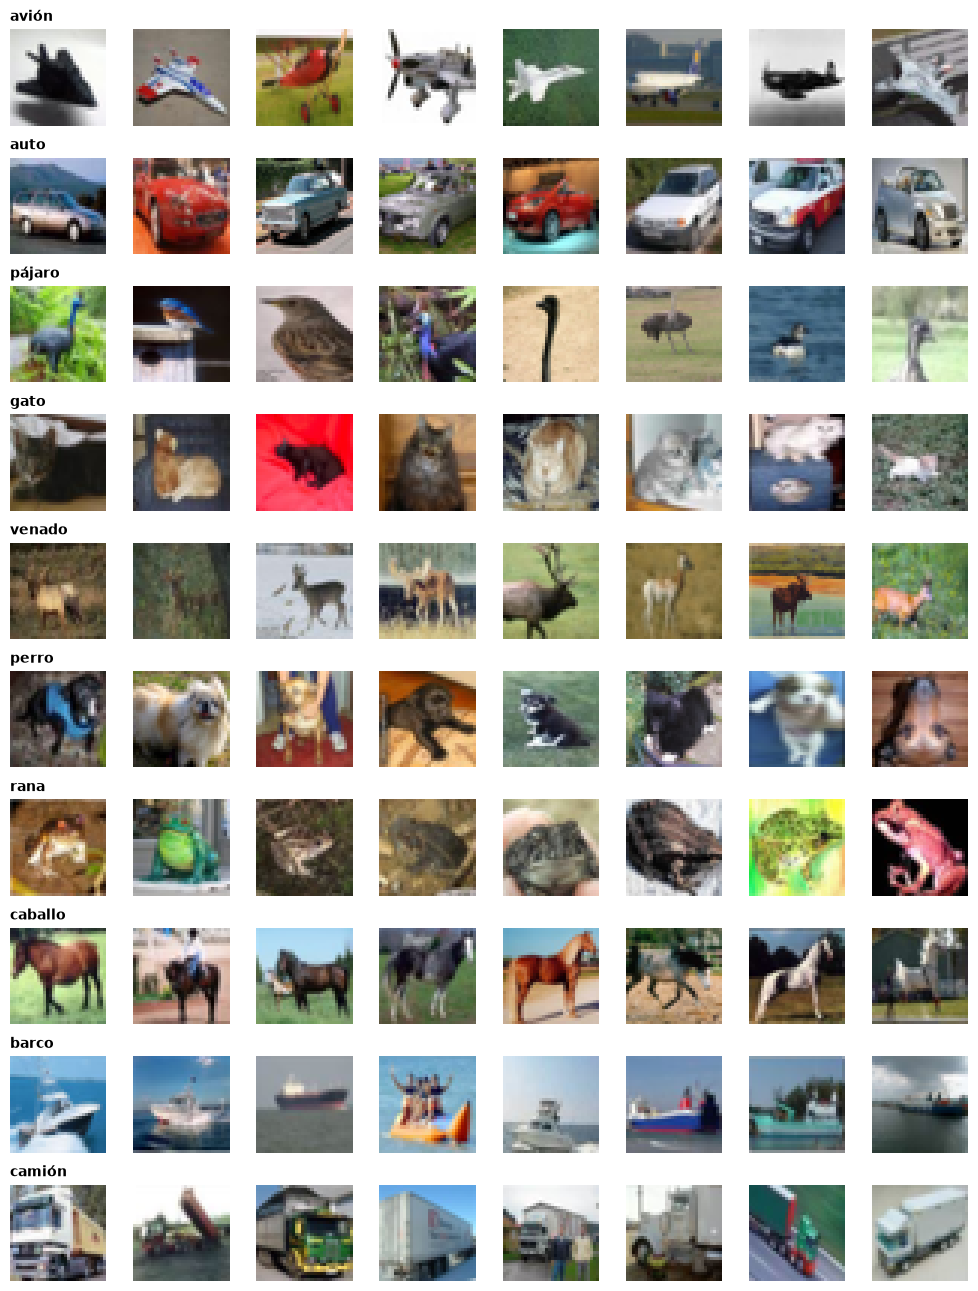

In [3]:
etiquetas_train = np.array(cifar_train_raw.targets)

fig, axes = plt.subplots(10, 8, figsize=(10, 13))
for clase in range(10):
    indices = np.flatnonzero(etiquetas_train == clase)[:8]
    for col, idx in enumerate(indices):
        axes[clase, col].imshow(cifar_train_raw[idx][0])
        axes[clase, col].axis("off")
    axes[clase, 0].set_title(CLASES_ES[clase], loc="left", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()

In [4]:
IMG_SIZE_TL = 128 if FAST_MODE else 224

transform_cnn = transforms.Compose([
    transforms.ToTensor(),                       # imagen → tensor con valores [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # [0, 1] → [-1, 1]
                         std=[0.5, 0.5, 0.5]),
])

transform_tl = transforms.Compose([
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # estadísticas de ImageNet
                         std=[0.229, 0.224, 0.225]),
])

print(transform_cnn)
print(transform_tl)

Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
BATCH_SIZE = 64
N_TRAIN, N_VAL, N_TEST = (10_000, 2_000, 2_000) if FAST_MODE else (45_000, 5_000, 10_000)

# Barajamos los índices UNA sola vez: todos los modelos usarán las mismas imágenes
generador = torch.Generator().manual_seed(SEED)
indices_train_oficial = torch.randperm(len(cifar_train_raw), generator=generador).tolist()
indices_test_oficial = torch.randperm(len(cifar_test_raw), generator=generador).tolist()

IDX_TRAIN = indices_train_oficial[:N_TRAIN]
IDX_VAL = indices_train_oficial[N_TRAIN:N_TRAIN + N_VAL]
IDX_TEST = indices_test_oficial[:N_TEST]


def crear_dataloaders(transform, batch_size=BATCH_SIZE):
    """Crea los DataLoaders de train/val/test de CIFAR-10 con un transform dado."""
    train_oficial = datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform)
    test_oficial = datasets.CIFAR10(root=DATA_DIR, train=False, transform=transform)

    train_ds = Subset(train_oficial, IDX_TRAIN)
    val_ds = Subset(train_oficial, IDX_VAL)
    test_ds = Subset(test_oficial, IDX_TEST)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    test_dl = DataLoader(test_ds, batch_size=batch_size)
    return train_dl, val_dl, test_dl


train_dl_cnn, val_dl_cnn, test_dl_cnn = crear_dataloaders(transform_cnn)
train_dl_tl, val_dl_tl, test_dl_tl = crear_dataloaders(transform_tl)

print(f"Train: {len(train_dl_cnn.dataset):,} | Val: {len(val_dl_cnn.dataset):,} | Test: {len(test_dl_cnn.dataset):,}")
print("Imágenes por clase en train:", np.bincount(etiquetas_train[IDX_TRAIN]))

Train: 10,000 | Val: 2,000 | Test: 2,000
Imágenes por clase en train: [1024  996  983  990  995  981 1029 1022  980 1000]


Batch de imágenes: torch.Size([64, 3, 32, 32])  ← [batch, canales, alto, ancho]
Batch de etiquetas: torch.Size([64])
Rango de valores: [-1.00, 1.00]
Batch para ResNet-18: torch.Size([64, 3, 128, 128])


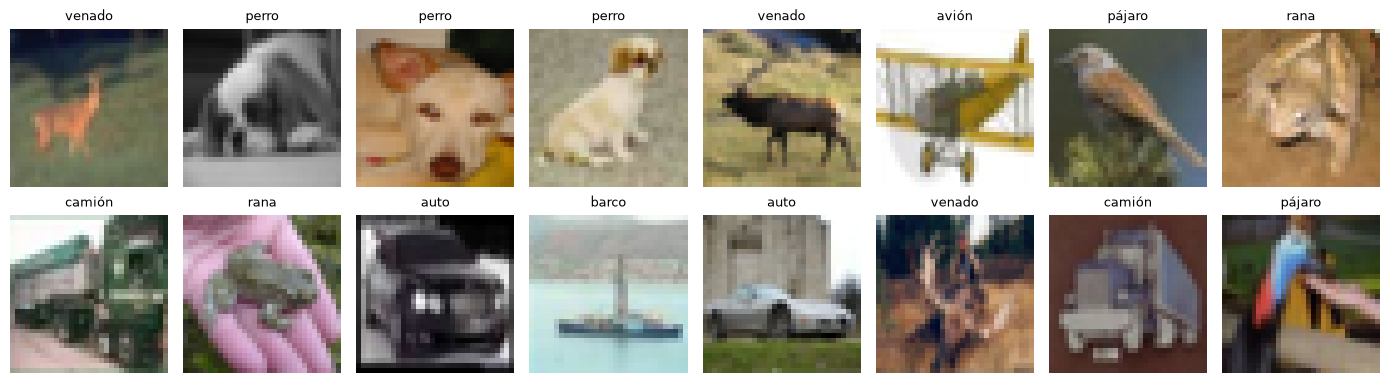

In [6]:
imagenes, etiquetas = next(iter(train_dl_cnn))

print(f"Batch de imágenes: {imagenes.shape}  ← [batch, canales, alto, ancho]")
print(f"Batch de etiquetas: {etiquetas.shape}")
print(f"Rango de valores: [{imagenes.min():.2f}, {imagenes.max():.2f}]")

imagenes_tl, _ = next(iter(train_dl_tl))
print(f"Batch para ResNet-18: {imagenes_tl.shape}")

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, etiqueta in zip(axes.flat, imagenes, etiquetas):
    img = img * 0.5 + 0.5                  # deshacemos la normalización para visualizar
    ax.imshow(img.permute(1, 2, 0))        # [canales, alto, ancho] → [alto, ancho, canales]
    ax.set_title(CLASES_ES[etiqueta], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Entrada:      torch.Size([4, 3, 32, 32])
Tras Conv2d:  torch.Size([4, 16, 32, 32])
Tras MaxPool: torch.Size([4, 16, 16, 16])


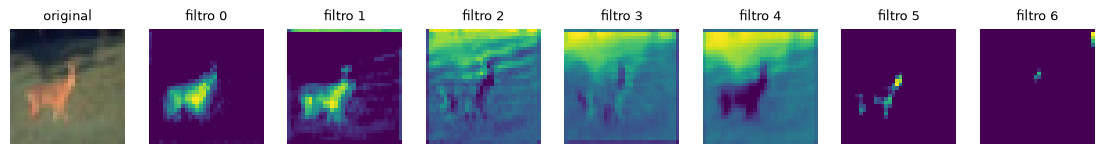

In [7]:
imagenes_muestra = imagenes[:4].to(DEVICE)
conv_demo = nn.Conv2d(3, 16, kernel_size=3, padding=1).to(DEVICE)
pool_demo = nn.MaxPool2d(2)

with torch.no_grad():
    mapas = torch.relu(conv_demo(imagenes_muestra))
    mapas_pool = pool_demo(mapas)

print("Entrada:     ", imagenes_muestra.shape)
print("Tras Conv2d: ", mapas.shape)
print("Tras MaxPool:", mapas_pool.shape)

assert mapas.shape == (4, 16, 32, 32)
assert mapas_pool.shape == (4, 16, 16, 16)

# Visualizamos lo que "ve" cada filtro (aún aleatorio) en la primera imagen
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
axes[0].imshow((imagenes_muestra[0].cpu() * 0.5 + 0.5).permute(1, 2, 0))
axes[0].set_title("original", fontsize=9)
for i, ax in enumerate(axes[1:]):
    ax.imshow(mapas[0, i].cpu(), cmap="viridis")
    ax.set_title(f"filtro {i}", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.show()

In [8]:
class LeNet5(nn.Module):
    """LeNet-5 (1998) adaptada: entrada RGB 32×32, ReLU y MaxPool."""

    def __init__(self, num_clases=10):
        super().__init__()
        self.extractor = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),    # 3×32×32 → 6×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 6×14×14
            nn.Conv2d(6, 16, kernel_size=5),   # → 16×10×10
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 16×5×5
            )
        self.clasificador = nn.Sequential(
            nn.Flatten(),                      # 16×5×5 → 400
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_clases),
            )

    def forward(self, x):
        x = self.extractor(x)        
        return self.clasificador(x) 


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


modelo_lenet = LeNet5().to(DEVICE)
salida = modelo_lenet(imagenes.to(DEVICE))

print(modelo_lenet)
print("\nSalida:", salida.shape)
print(f"Parámetros entrenables: {contar_parametros(modelo_lenet):,}")

assert salida.shape == (imagenes.shape[0], 10)
assert contar_parametros(modelo_lenet) == 62_006

LeNet5(
  (extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

Salida: torch.Size([64, 10])
Parámetros entrenables: 62,006


In [10]:
def entrenar_una_epoca(modelo, dataloader, criterio, optimizador):
    """Una pasada completa por los datos de entrenamiento."""
    modelo.train()                          # modo entrenamiento
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)

        optimizador.zero_grad()                 # 0. limpiar gradientes anteriores
        logits = modelo(imagenes)               # 1. forward: la red predice
        perdida = criterio(logits, etiquetas)   # 2. loss: ¿qué tan mal?
        perdida.backward()                      # 3. backward: calcular gradientes
        optimizador.step()                      # 4. step: ajustar pesos

        perdida_total += perdida.item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n


@torch.no_grad()
def evaluar(modelo, dataloader, criterio):
    """Mide loss y accuracy sin modificar el modelo."""
    modelo.eval()                           # modo evaluación
    perdida_total, aciertos = 0.0, 0

    for imagenes, etiquetas in dataloader:
        imagenes = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE)
        logits = modelo(imagenes)
        perdida_total += criterio(logits, etiquetas).item() * len(etiquetas)
        aciertos += (logits.argmax(dim=1) == etiquetas).sum().item()

    n = len(dataloader.dataset)
    return perdida_total / n, aciertos / n



def fit(modelo, train_dl, val_dl, criterio, optimizador, epocas):
    """Entrena el modelo y guarda el historial de métricas."""
    historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoca in range(1, epocas + 1):
        train_loss, train_acc = entrenar_una_epoca(modelo, train_dl, criterio, optimizador)
        val_loss, val_acc = evaluar(modelo, val_dl, criterio)

        historial["train_loss"].append(train_loss)
        historial["train_acc"].append(train_acc)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)

        print(f"Época {epoca}/{epocas} | "
              f"train loss: {train_loss:.4f}, acc: {train_acc:.2%} | "
              f"val loss: {val_loss:.4f}, acc: {val_acc:.2%}")
    return historial  
def graficar_historial(historial, titulo):
    """Curvas de loss y accuracy durante el entrenamiento (ya viene lista)."""
    epocas = range(1, len(historial["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epocas, historial["train_loss"], "o-", label="train")
    ax1.plot(epocas, historial["val_loss"], "s-", label="validation")
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{titulo} — Loss (↓ mejor)"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epocas, historial["train_acc"], "o-", label="train")
    ax2.plot(epocas, historial["val_acc"], "s-", label="validation")
    ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{titulo} — Accuracy (↑ mejor)"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Comprobación con un modelo sin entrenar
criterio = nn.CrossEntropyLoss()
loss_azar, acc_azar = evaluar(LeNet5().to(DEVICE), val_dl_cnn, criterio)
print(f"Modelo sin entrenar → loss: {loss_azar:.4f}, accuracy: {acc_azar:.2%}")

assert 2.0 < loss_azar < 2.6
assert 0.03 < acc_azar < 0.20



Modelo sin entrenar → loss: 2.3045, accuracy: 7.55%


Época 1/10 | train loss: 1.9503, acc: 28.81% | val loss: 1.7390, acc: 34.95%
Época 2/10 | train loss: 1.6557, acc: 39.78% | val loss: 1.6307, acc: 40.15%
Época 3/10 | train loss: 1.5429, acc: 44.11% | val loss: 1.5969, acc: 41.40%
Época 4/10 | train loss: 1.4606, acc: 47.31% | val loss: 1.4749, acc: 45.95%
Época 5/10 | train loss: 1.3974, acc: 49.80% | val loss: 1.4732, acc: 45.05%
Época 6/10 | train loss: 1.3339, acc: 52.03% | val loss: 1.4448, acc: 47.85%
Época 7/10 | train loss: 1.2836, acc: 53.44% | val loss: 1.4379, acc: 47.60%
Época 8/10 | train loss: 1.2362, acc: 55.00% | val loss: 1.3992, acc: 48.45%
Época 9/10 | train loss: 1.1722, acc: 58.10% | val loss: 1.4070, acc: 49.75%
Época 10/10 | train loss: 1.1348, acc: 59.19% | val loss: 1.3749, acc: 50.95%


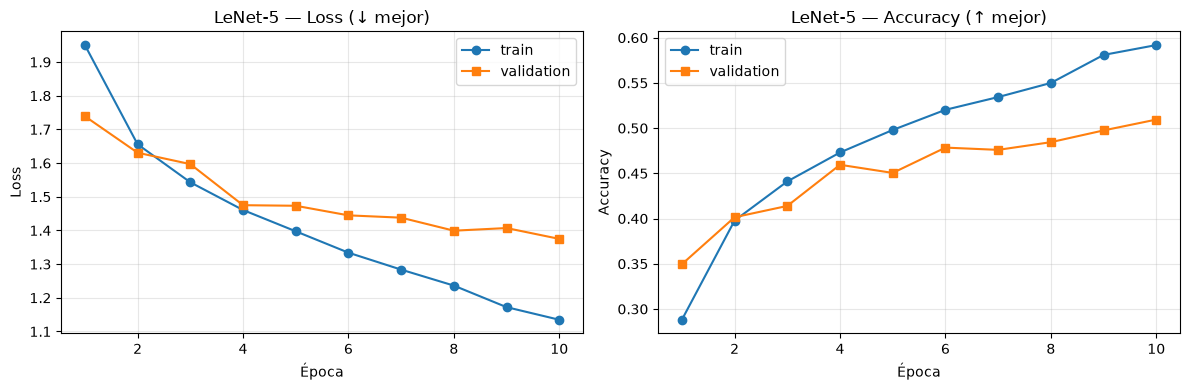

In [11]:
fijar_semilla()

modelo_lenet = LeNet5().to(DEVICE)
criterio = nn.CrossEntropyLoss()
optimizador_lenet = torch.optim.Adam(modelo_lenet.parameters(), lr=1e-3)

historial_lenet = fit(modelo_lenet, train_dl_cnn, val_dl_cnn, criterio, optimizador_lenet, EPOCAS_CNN)
graficar_historial(historial_lenet, "LeNet-5")

In [12]:
class CNNPropia(nn.Module):
    """CNN de 3 bloques Conv → ReLU → MaxPool para imágenes 3×32×32."""

    def __init__(self, num_clases=10):
        super().__init__()
        self.extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                            # → 32×16×16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                            # → 64×8×8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                            # → 128×4×4
        )
        self.clasificador = nn.Sequential(
            nn.Flatten(),                               # 128×4×4 → 2,048
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_clases),
        )

    def forward(self, x):
        x = self.extractor(x)
        return self.clasificador(x)


modelo_cnn = CNNPropia().to(DEVICE)

# Recorrido capa por capa: así verificamos las formas antes de entrenar
x = imagenes[:4].to(DEVICE)
print(f"{'entrada':>10s} → {tuple(x.shape)}")
with torch.no_grad():
    for capa in modelo_cnn.extractor:
        x = capa(x)
        print(f"{capa.__class__.__name__:>10s} → {tuple(x.shape)}")

salida = modelo_cnn(imagenes.to(DEVICE))
print("\nSalida:", salida.shape)
print(f"Parámetros entrenables: {contar_parametros(modelo_cnn):,} "
      f"(LeNet-5: {contar_parametros(modelo_lenet):,})")

assert x.shape == (4, 128, 4, 4)
assert salida.shape == (imagenes.shape[0], 10)
assert contar_parametros(modelo_cnn) == 620_362

   entrada → (4, 3, 32, 32)
    Conv2d → (4, 32, 32, 32)
      ReLU → (4, 32, 32, 32)
 MaxPool2d → (4, 32, 16, 16)
    Conv2d → (4, 64, 16, 16)
      ReLU → (4, 64, 16, 16)
 MaxPool2d → (4, 64, 8, 8)
    Conv2d → (4, 128, 8, 8)
      ReLU → (4, 128, 8, 8)
 MaxPool2d → (4, 128, 4, 4)

Salida: torch.Size([64, 10])
Parámetros entrenables: 620,362 (LeNet-5: 62,006)


Época 1/10 | train loss: 1.8727, acc: 30.75% | val loss: 1.5949, acc: 41.50%
Época 2/10 | train loss: 1.4968, acc: 45.32% | val loss: 1.3890, acc: 48.60%
Época 3/10 | train loss: 1.3134, acc: 52.49% | val loss: 1.3074, acc: 52.00%
Época 4/10 | train loss: 1.1873, acc: 57.04% | val loss: 1.2456, acc: 54.05%
Época 5/10 | train loss: 1.0781, acc: 60.78% | val loss: 1.1335, acc: 58.30%
Época 6/10 | train loss: 0.9581, acc: 65.94% | val loss: 1.0793, acc: 61.50%
Época 7/10 | train loss: 0.8546, acc: 69.11% | val loss: 1.1047, acc: 59.75%
Época 8/10 | train loss: 0.7753, acc: 72.72% | val loss: 1.0611, acc: 62.70%
Época 9/10 | train loss: 0.6775, acc: 76.41% | val loss: 1.0555, acc: 62.85%
Época 10/10 | train loss: 0.5992, acc: 78.73% | val loss: 1.1187, acc: 61.25%


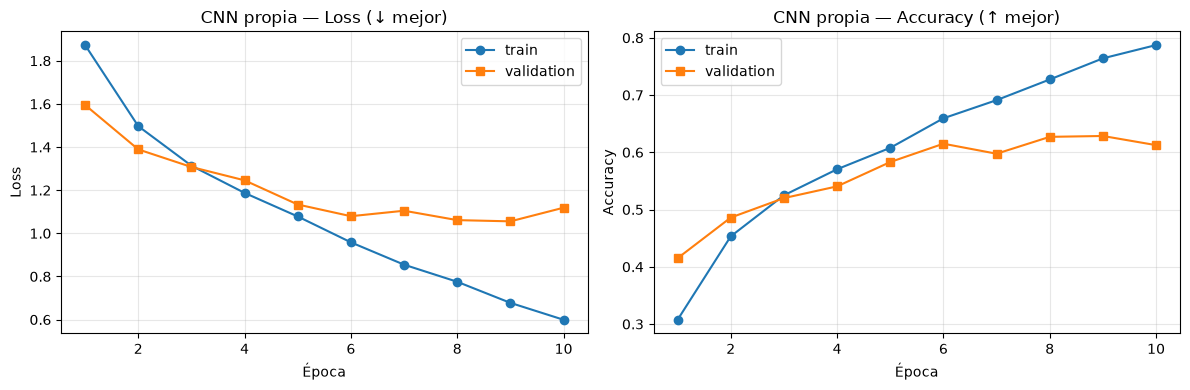

In [13]:
fijar_semilla()

modelo_cnn = CNNPropia().to(DEVICE)
optimizador_cnn = torch.optim.Adam(modelo_cnn.parameters(), lr=1e-3)

historial_cnn = fit(modelo_cnn, train_dl_cnn, val_dl_cnn, criterio, optimizador_cnn, EPOCAS_CNN)
graficar_historial(historial_cnn, "CNN propia")

In [19]:
import timm

fijar_semilla()
modelo_tl = timm.create_model("resnet18", pretrained=True, num_classes=10)

# 1) congelar TODOS los pesos
for parametro in modelo_tl.parameters():
    parametro.requires_grad = False

# 2) descongelar solo los parámetros del clasificador (get_classifier)
for parametro in modelo_tl.get_classifier().parameters():
    parametro.requires_grad = True

modelo_tl = modelo_tl.to(DEVICE)

salida_tl = modelo_tl(imagenes_tl.to(DEVICE))
total = sum(p.numel() for p in modelo_tl.parameters())
print("Clasificador:", modelo_tl.get_classifier())
print("Salida:", salida_tl.shape)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {contar_parametros(modelo_tl):,} "
      f"({contar_parametros(modelo_tl) / total:.2%} del total)")

assert salida_tl.shape == (imagenes_tl.shape[0], 10)
assert contar_parametros(modelo_tl) == 512 * 10 + 10

d:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\Users\ClientAdm\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an adminis

Clasificador: Linear(in_features=512, out_features=10, bias=True)
Salida: torch.Size([64, 10])
Parámetros totales:      11,181,642
Parámetros entrenables:  5,130 (0.05% del total)


Época 1/3 | train loss: 1.4969, acc: 58.71% | val loss: 1.1016, acc: 69.25%
Época 2/3 | train loss: 0.9948, acc: 70.33% | val loss: 0.9120, acc: 71.90%
Época 3/3 | train loss: 0.8719, acc: 72.61% | val loss: 0.8424, acc: 73.70%


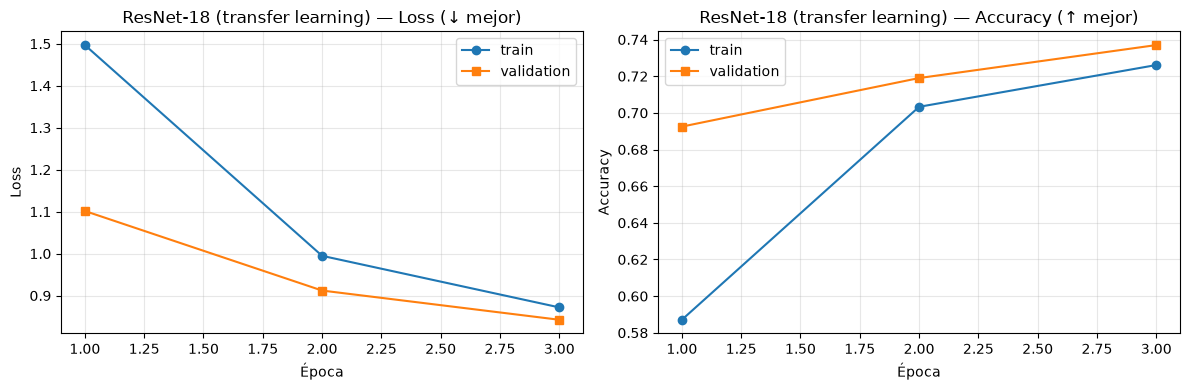

In [20]:
optimizador_tl = torch.optim.Adam(
    (p for p in modelo_tl.parameters() if p.requires_grad), lr=1e-3
)

historial_tl = fit(modelo_tl, train_dl_tl, val_dl_tl, criterio, optimizador_tl, EPOCAS_TL)
graficar_historial(historial_tl, "ResNet-18 (transfer learning)")

Época 1/3 | train loss: 1.8249, acc: 48.65% | val loss: 1.1265, acc: 72.90%
Época 2/3 | train loss: 0.8289, acc: 78.60% | val loss: 0.5811, acc: 84.05%
Época 3/3 | train loss: 0.4890, acc: 85.66% | val loss: 0.4431, acc: 87.00%


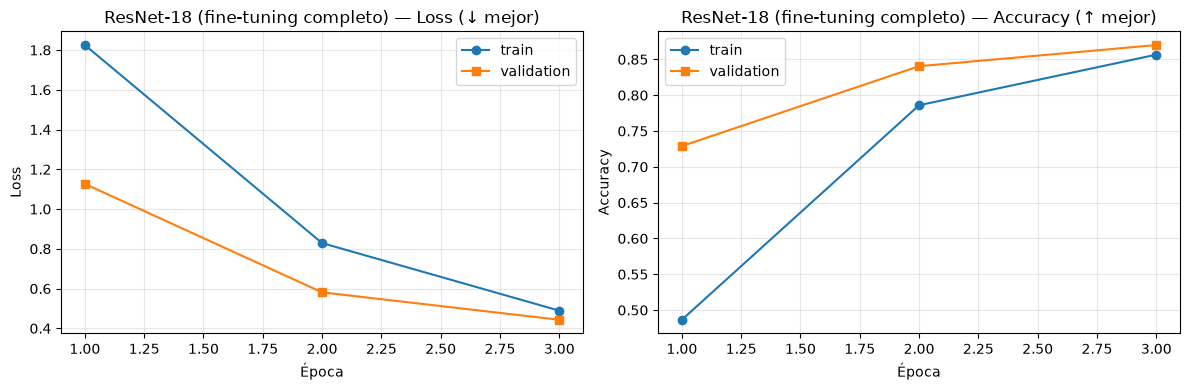

In [21]:
fijar_semilla()
modelo_ft = timm.create_model("resnet18", pretrained=True, num_classes=10).to(DEVICE)

for parametro in modelo_ft.parameters():
    parametro.requires_grad = True

optimizador_ft = torch.optim.Adam(modelo_ft.parameters(), lr=1e-4)
historial_ft = fit(modelo_ft, train_dl_tl, val_dl_tl, criterio, optimizador_ft, EPOCAS_FT)
graficar_historial(historial_ft, "ResNet-18 (fine-tuning completo)")

In [22]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)


@torch.no_grad()
def obtener_predicciones(modelo, dataloader):
    """Devuelve (etiquetas reales, etiquetas predichas) de todo un dataloader."""
    modelo.eval()
    y_real, y_pred = [], []
    for imagenes, etiquetas in dataloader:
        logits = modelo(imagenes.to(DEVICE))
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
        y_real.extend(etiquetas.tolist())
    return y_real, y_pred


modelos_finales = [
    ("LeNet-5", modelo_lenet, test_dl_cnn),
    ("CNN propia", modelo_cnn, test_dl_cnn),
    ("ResNet-18 (TL)", modelo_tl, test_dl_tl),
    ("ResNet-18 (FT)", modelo_ft, test_dl_tl),    # ← bórrala si no hiciste el bonus
]

resultados = {}
predicciones = {}
for nombre, modelo, test_dl in modelos_finales:
    y_real, y_pred = obtener_predicciones(modelo, test_dl)
    predicciones[nombre] = (y_real, y_pred)
    resultados[nombre] = accuracy_score(y_real, y_pred)
    print(f"{nombre:>15s} → accuracy en test: {resultados[nombre]:.2%}")

        LeNet-5 → accuracy en test: 53.55%
     CNN propia → accuracy en test: 64.50%
 ResNet-18 (TL) → accuracy en test: 74.10%
 ResNet-18 (FT) → accuracy en test: 86.35%


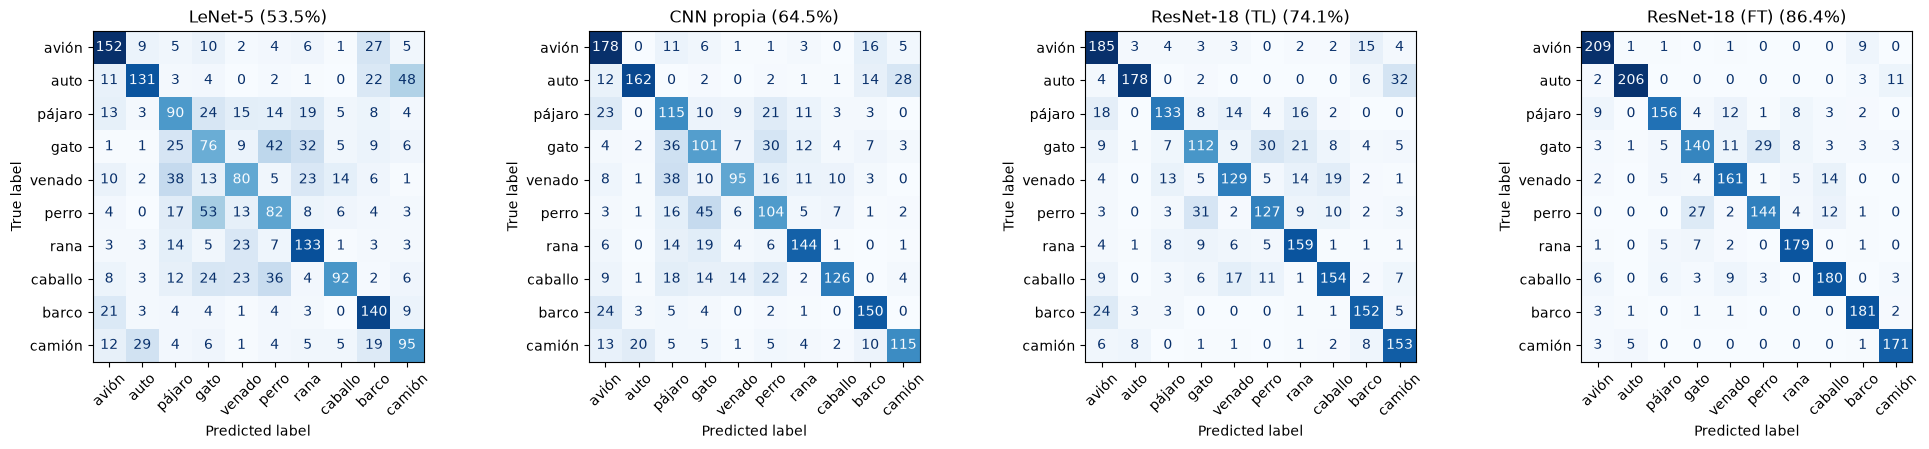

📊 Classification report — ResNet-18 (FT)

              precision    recall  f1-score   support

       avión       0.88      0.95      0.91       221
        auto       0.96      0.93      0.94       222
      pájaro       0.88      0.80      0.84       195
        gato       0.75      0.68      0.71       206
      venado       0.81      0.84      0.82       192
       perro       0.81      0.76      0.78       190
        rana       0.88      0.92      0.90       195
     caballo       0.85      0.86      0.85       210
       barco       0.90      0.96      0.93       189
      camión       0.90      0.95      0.92       180

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [23]:
# Una matriz de confusión por modelo (una fila de subplots)
fig, axes = plt.subplots(1, len(modelos_finales), figsize=(5 * len(modelos_finales), 4.5))
for ax, (nombre, (y_real, y_pred)) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred, display_labels=CLASES_ES, ax=ax,
        colorbar=False, cmap="Blues", xticks_rotation=45,
    )
    ax.set_title(f"{nombre} ({resultados[nombre]:.1%})")
plt.tight_layout()
plt.show()

# Classification report del modelo con mayor accuracy
mejor_nombre = max(resultados, key=resultados.get)
y_real, y_pred = predicciones[mejor_nombre]

print(f"📊 Classification report — {mejor_nombre}\n")
print(classification_report(y_real, y_pred, target_names=CLASES_ES))

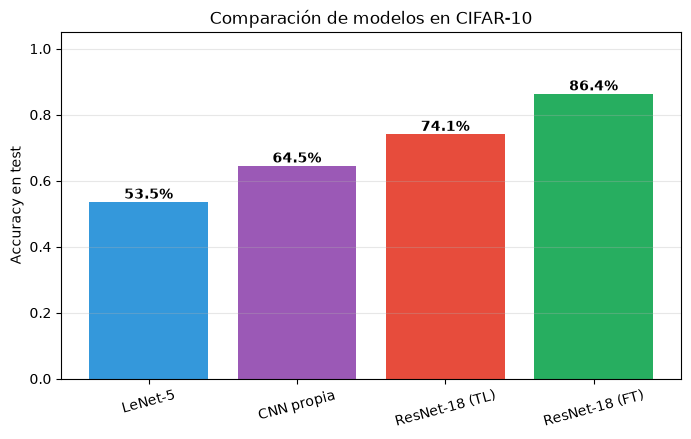

          Modelo |  Parám. totales |  Parám. entrenados | Accuracy test
         LeNet-5 |          62,006 |             62,006 |       53.55%
      CNN propia |         620,362 |            620,362 |       64.50%
  ResNet-18 (TL) |      11,181,642 |              5,130 |       74.10%
  ResNet-18 (FT) |      11,181,642 |         11,181,642 |       86.35%


In [24]:
# Gráfico de barras con la accuracy en test de cada modelo
fig, ax = plt.subplots(figsize=(8, 4.5))
colores = ["#3498db", "#9b59b6", "#e74c3c", "#27ae60"][:len(resultados)]
barras = ax.bar(resultados.keys(), resultados.values(), color=colores)
ax.bar_label(barras, fmt=lambda v: f"{v:.1%}", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy en test")
ax.set_title("Comparación de modelos en CIFAR-10")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.show()

# Tabla: parámetros totales, entrenados y accuracy en test
print(f"{'Modelo':>16s} | {'Parám. totales':>15s} | {'Parám. entrenados':>18s} | {'Accuracy test':>13s}")
for nombre, modelo, _ in modelos_finales:
    totales = sum(p.numel() for p in modelo.parameters())
    entrenados = contar_parametros(modelo)
    print(f"{nombre:>16s} | {totales:>15,} | {entrenados:>18,} | {resultados[nombre]:>12.2%}")

Clase real: perro


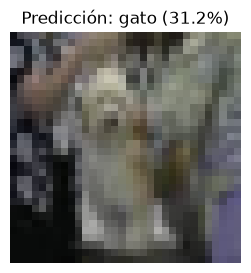

      gato: 31.2%
     perro: 17.0%
      rana: 16.0%
Clase real: caballo


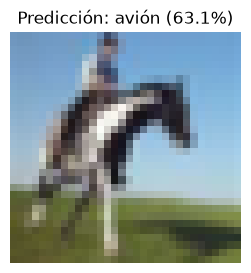

     avión: 63.1%
    pájaro: 18.7%
   caballo: 11.0%
Clase real: perro


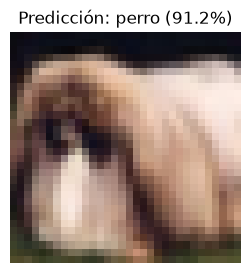

     perro: 91.2%
   caballo: 4.1%
      gato: 3.0%


In [25]:
@torch.no_grad()
def predecir(imagen_pil, modelo=modelo_tl, transform=transform_tl):
    """Clasifica una imagen PIL y la muestra junto a la predicción."""
    modelo.eval()
    tensor = transform(imagen_pil).unsqueeze(0).to(DEVICE)
    probabilidades = torch.softmax(modelo(tensor), dim=1)[0]
    prediccion = probabilidades.argmax().item()

    plt.figure(figsize=(3, 3))
    plt.imshow(imagen_pil)
    plt.axis("off")
    plt.title(f"Predicción: {CLASES_ES[prediccion]} ({probabilidades[prediccion]:.1%})")
    plt.show()

    top3 = probabilidades.topk(3)
    for prob, clase in zip(top3.values, top3.indices):
        print(f"  {CLASES_ES[clase]:>8s}: {prob:.1%}")


for idx in random.sample(IDX_TEST, 3):
    imagen, etiqueta = cifar_test_raw[idx]
    print(f"Clase real: {CLASES_ES[etiqueta]}")
    predecir(imagen)

In [26]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

torch.save(modelo_cnn.state_dict(), MODELS_DIR / "cnn_propia_cifar10.pt")
torch.save(modelo_tl.state_dict(), MODELS_DIR / "resnet18_cifar10.pt")

for archivo in sorted(MODELS_DIR.glob("*cifar10.pt")):
    tamano_mb = archivo.stat().st_size / 1024**2
    print(f"✅ {archivo.name} ({tamano_mb:.1f} MB)")

cnn_cargada = CNNPropia()
cnn_cargada.load_state_dict(
    torch.load(MODELS_DIR / "cnn_propia_cifar10.pt", map_location=DEVICE)
)
cnn_cargada = cnn_cargada.to(DEVICE).eval()

y_real, y_pred = obtener_predicciones(cnn_cargada, test_dl_cnn)
acc_cargada = accuracy_score(y_real, y_pred)
print(f"Accuracy de la CNN cargada desde disco: {acc_cargada:.2%} (original: {resultados['CNN propia']:.2%})")

assert acc_cargada == resultados["CNN propia"]

✅ cnn_propia_cifar10.pt (2.4 MB)
✅ resnet18_cifar10.pt (42.7 MB)
Accuracy de la CNN cargada desde disco: 64.50% (original: 64.50%)
